## 1. Loading and Exploring the Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/students_dataset.csv")

# Basic look at the data
print(df.shape)
df.head()

(500, 8)


,student_id,attendance_percentage,avg_test_score,assignments_submitted_pct,study_hours_per_week,previous_semester_gpa,extracurricular_participation,risk_label
0,S1000,82.5,81.7,100.0,13.9,5.49,1,Low
1,S1001,72.9,99.4,93.9,7.2,6.28,1,Low
2,S1002,84.7,39.8,80.9,5.9,5.31,0,Medium
3,S1003,97.8,75.1,70.3,10.0,6.04,0,Low
4,S1004,71.5,53.3,90.5,9.1,3.66,0,High


## 2. Risk Level Distribution

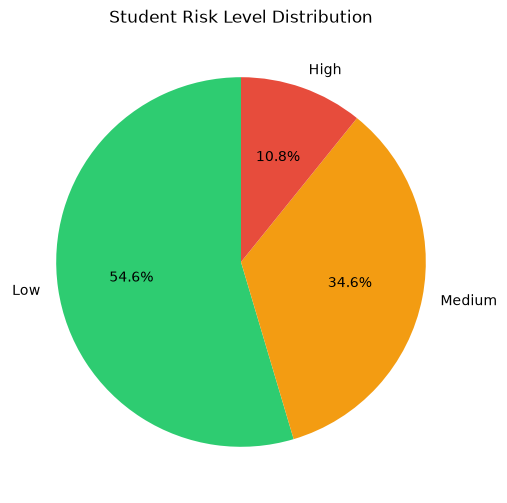

In [2]:
# Chart 1: Risk Level Distribution
risk_counts = df['risk_label'].value_counts()

plt.figure(figsize=(6, 6))
colors = ['#2ecc71', '#f39c12', '#e74c3c']  # green, orange, red
plt.pie(risk_counts, labels=risk_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Student Risk Level Distribution')
plt.show()

## 3. Attendance & Test Score Overview

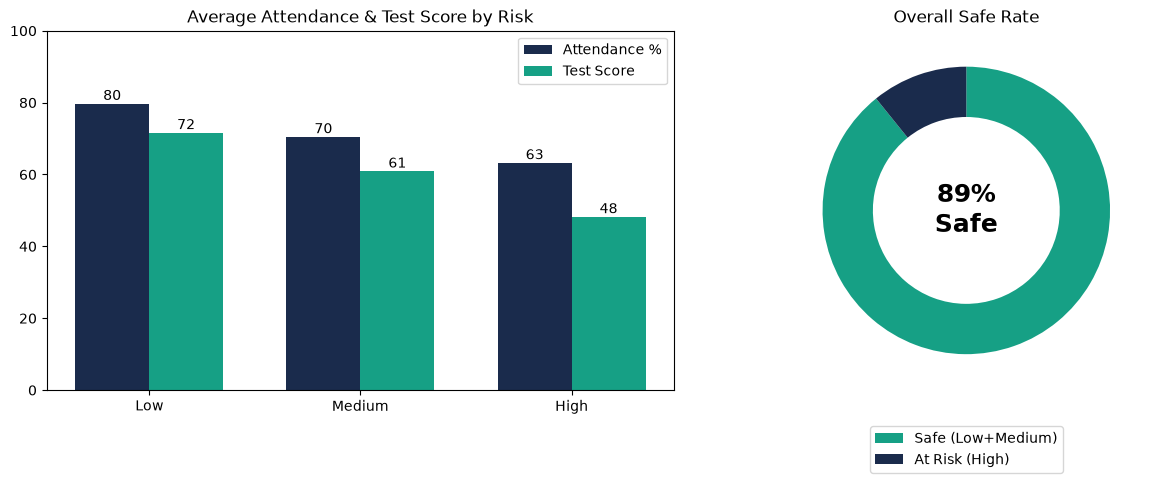

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# LEFT: Bar chart - average attendance and test score by risk level
avg_by_risk = df.groupby('risk_label')[['attendance_percentage', 'avg_test_score']].mean()
avg_by_risk = avg_by_risk.reindex(['Low', 'Medium', 'High'])

x = np.arange(len(avg_by_risk))
width = 0.35
axes[0].bar(x - width/2, avg_by_risk['attendance_percentage'], width, label='Attendance %', color='#1a2b4c')
axes[0].bar(x + width/2, avg_by_risk['avg_test_score'], width, label='Test Score', color='#16a085')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Low', 'Medium', 'High'])
axes[0].set_title('Average Attendance & Test Score by Risk')
axes[0].set_ylim(0, 100)
axes[0].legend()

# Add value labels on top of bars
for i in range(len(avg_by_risk)):
    axes[0].text(i - width/2, avg_by_risk['attendance_percentage'].iloc[i] + 1, 
                 f"{avg_by_risk['attendance_percentage'].iloc[i]:.0f}", ha='center')
    axes[0].text(i + width/2, avg_by_risk['avg_test_score'].iloc[i] + 1, 
                 f"{avg_by_risk['avg_test_score'].iloc[i]:.0f}", ha='center')

# RIGHT: Donut chart - overall "Safe" vs "At Risk" rate
safe_pct = (df['risk_label'].isin(['Low', 'Medium']).sum() / len(df)) * 100
at_risk_pct = 100 - safe_pct

axes[1].pie([safe_pct, at_risk_pct], colors=['#16a085', '#1a2b4c'], startangle=90,
            counterclock=False, wedgeprops=dict(width=0.35))
axes[1].text(0, 0, f"{safe_pct:.0f}%\nSafe", ha='center', va='center', fontsize=18, fontweight='bold')
axes[1].set_title('Overall Safe Rate')
axes[1].legend(['Safe (Low+Medium)', 'At Risk (High)'], loc='lower center', bbox_to_anchor=(0.5, -0.25))

plt.tight_layout()
plt.show()

## 4. Risk Level Trend by Attendance Range

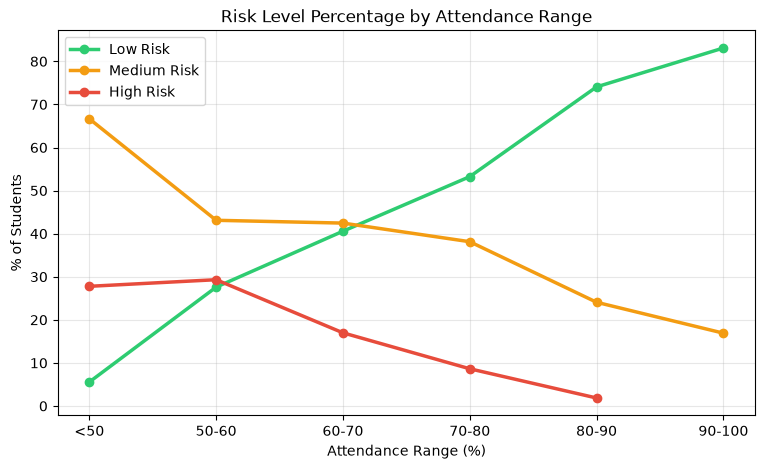

In [12]:
# Chart 3: Trend lines - % of Low/Medium/High risk students by attendance range
df['attendance_bracket'] = pd.cut(df['attendance_percentage'], 
                                    bins=[0, 50, 60, 70, 80, 90, 100],
                                    labels=['<50', '50-60', '60-70', '70-80', '80-90', '90-100'])

risk_pct_by_bracket = df.groupby('attendance_bracket')['risk_label'].value_counts(normalize=True).unstack() * 100
risk_pct_by_bracket = risk_pct_by_bracket[['Low', 'Medium', 'High']]  # ensure column order

plt.figure(figsize=(9, 5))
plt.plot(risk_pct_by_bracket.index, risk_pct_by_bracket['Low'], marker='o', linewidth=2.5, color='#2ecc71', label='Low Risk')
plt.plot(risk_pct_by_bracket.index, risk_pct_by_bracket['Medium'], marker='o', linewidth=2.5, color='#f39c12', label='Medium Risk')
plt.plot(risk_pct_by_bracket.index, risk_pct_by_bracket['High'], marker='o', linewidth=2.5, color='#e74c3c', label='High Risk')

plt.xlabel('Attendance Range (%)')
plt.ylabel('% of Students')
plt.title('Risk Level Percentage by Attendance Range')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Preparing Data for Machine Learning

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Features (inputs) and target (what we want to predict)
feature_cols = ['attendance_percentage', 'avg_test_score', 'assignments_submitted_pct', 
                 'study_hours_per_week', 'previous_semester_gpa', 'extracurricular_participation']

X = df[feature_cols]
y = df['risk_label']

# Split into training data (80%) and testing data (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (400, 6)
Testing set size: (100, 6)


## 6. Training and Comparing Models

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions, average='weighted'),
        "Recall": recall_score(y_test, predictions, average='weighted'),
        "F1 Score": f1_score(y_test, predictions, average='weighted')
    })

results_df = pd.DataFrame(results)
results_df

c:\Users\ARYAN\anaconda3\envs\student-risk\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.71,0.718584,0.71,0.707665
1,Decision Tree,0.65,0.655826,0.65,0.652284
2,Random Forest,0.68,0.675198,0.68,0.671853


## 7. Comparing Model Performance

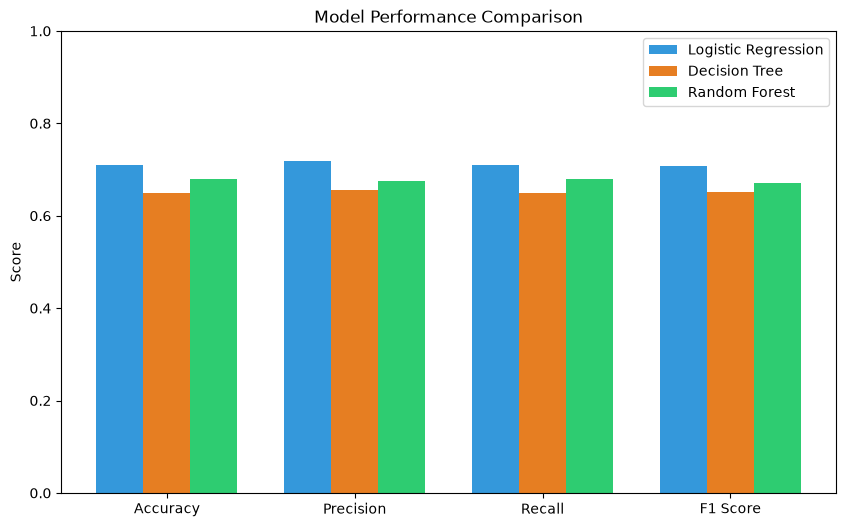

In [16]:
# Chart: Comparing all 3 models across all 4 metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#3498db', '#e67e22', '#2ecc71']
for i, model_name in enumerate(results_df['Model']):
    values = results_df.loc[results_df['Model'] == model_name, metrics].values.flatten()
    ax.bar(x + (i - 1) * width, values, width, label=model_name, color=colors[i])

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.set_title('Model Performance Comparison')
ax.legend()
plt.show()

## 8. Confusion Matrix for Best Model (Logistic Regression)

c:\Users\ARYAN\anaconda3\envs\student-risk\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


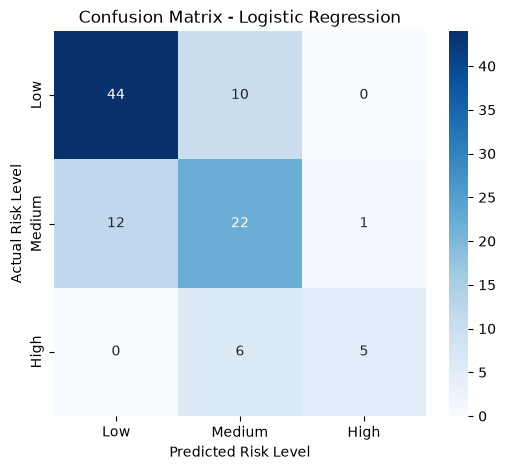

In [17]:
from sklearn.metrics import confusion_matrix

# Retrain Logistic Regression (or reuse it if still in memory) and get predictions
best_model = LogisticRegression(max_iter=1000, random_state=42)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

labels_order = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels_order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.xlabel('Predicted Risk Level')
plt.ylabel('Actual Risk Level')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

## 9. Saving the Model for the Dashboard

In [18]:
import joblib

# Save the trained Logistic Regression model to a file
joblib.dump(best_model, '../app/risk_model.pkl')
print("Model saved successfully!")

Model saved successfully!
